In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
import zipfile

zip_path = "/content/archive (2).zip"   # change name if different
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/yes
/content/dataset/brain_tumor_dataset
/content/dataset/brain_tumor_dataset/yes
/content/dataset/brain_tumor_dataset/no
/content/dataset/no


In [ ]:
import os
import shutil
import random

base_path = "/content/dataset"

# Source folders (ALL possible locations)
yes_paths = [
    base_path + "/yes",
    base_path + "/brain_tumor_dataset/yes"
]

no_paths = [
    base_path + "/no",
    base_path + "/brain_tumor_dataset/no"
]

# Target folders
train_tumor = base_path + "/train/tumor"
train_no = base_path + "/train/no_tumor"
test_tumor = base_path + "/test/tumor"
test_no = base_path + "/test/no_tumor"

# Create folders
os.makedirs(train_tumor, exist_ok=True)
os.makedirs(train_no, exist_ok=True)
os.makedirs(test_tumor, exist_ok=True)
os.makedirs(test_no, exist_ok=True)

# Function to collect all files from multiple folders
def collect_files(paths):
    all_files = []
    for path in paths:
        if os.path.exists(path):
            for file in os.listdir(path):
                full_path = os.path.join(path, file)
                if os.path.isfile(full_path):
                    all_files.append(full_path)
    return all_files

# Collect data
yes_files = collect_files(yes_paths)
no_files = collect_files(no_paths)

# Shuffle
random.shuffle(yes_files)
random.shuffle(no_files)

# Split function
def split(files, train_dest, test_dest, ratio=0.8):
    split_size = int(len(files) * ratio)

    train_files = files[:split_size]
    test_files = files[split_size:]

    for f in train_files:
        shutil.copy(f, train_dest)

    for f in test_files:
        shutil.copy(f, test_dest)

# Apply split
split(yes_files, train_tumor, test_tumor)
split(no_files, train_no, test_no)

print("✅ Dataset merged + split successfully!")

✅ Dataset merged + split successfully!


In [ ]:
for root, dirs, files in os.walk("/content/dataset"):
    print(root, len(files))

/content/dataset 0
/content/dataset/test 0
/content/dataset/test/no_tumor 38
/content/dataset/test/tumor 58
/content/dataset/yes 155
/content/dataset/brain_tumor_dataset 0
/content/dataset/brain_tumor_dataset/yes 155
/content/dataset/brain_tumor_dataset/no 98
/content/dataset/train 0
/content/dataset/train/no_tumor 96
/content/dataset/train/tumor 151
/content/dataset/no 98


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 247 images belonging to 2 classes.
Found 96 images belonging to 2 classes.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu', name="last_conv"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') #gives probability for binary classes
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6680 - loss: 0.6716 - val_accuracy: 0.7604 - val_loss: 0.5362
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7652 - loss: 0.5022 - val_accuracy: 0.7917 - val_loss: 0.4838
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8097 - loss: 0.4562 - val_accuracy: 0.8229 - val_loss: 0.4522
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8421 - loss: 0.4179 - val_accuracy: 0.8750 - val_loss: 0.4081
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8745 - loss: 0.3522 - val_accuracy: 0.8854 - val_loss: 0.3247
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8907 - loss: 0.2686 - val_accuracy: 0.9479 - val_loss: 0.2605
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9514 - loss: 0.1726 - val_accuracy: 0.9375 - val_loss: 0.1730
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9636 - loss: 0.1087 - val_accuracy: 0.9688 - val_loss: 0.1290
Epoch 9/10


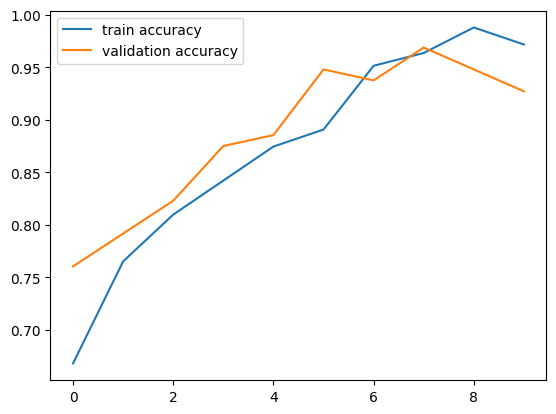

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img('/content/Image-with-tumor.jpg', target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) #expands dimension array of image from [128,128,3] to [1,128,128,3] bcz keras or tensorflow expect this type of input [batchsize,h,w,channel] even with single image testing
img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0] > 0.5: #sigmoid returned [prob_tumor,prob_not_tumor]
    print("Tumor Detected")
else:
    print("No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Tumor Detected


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


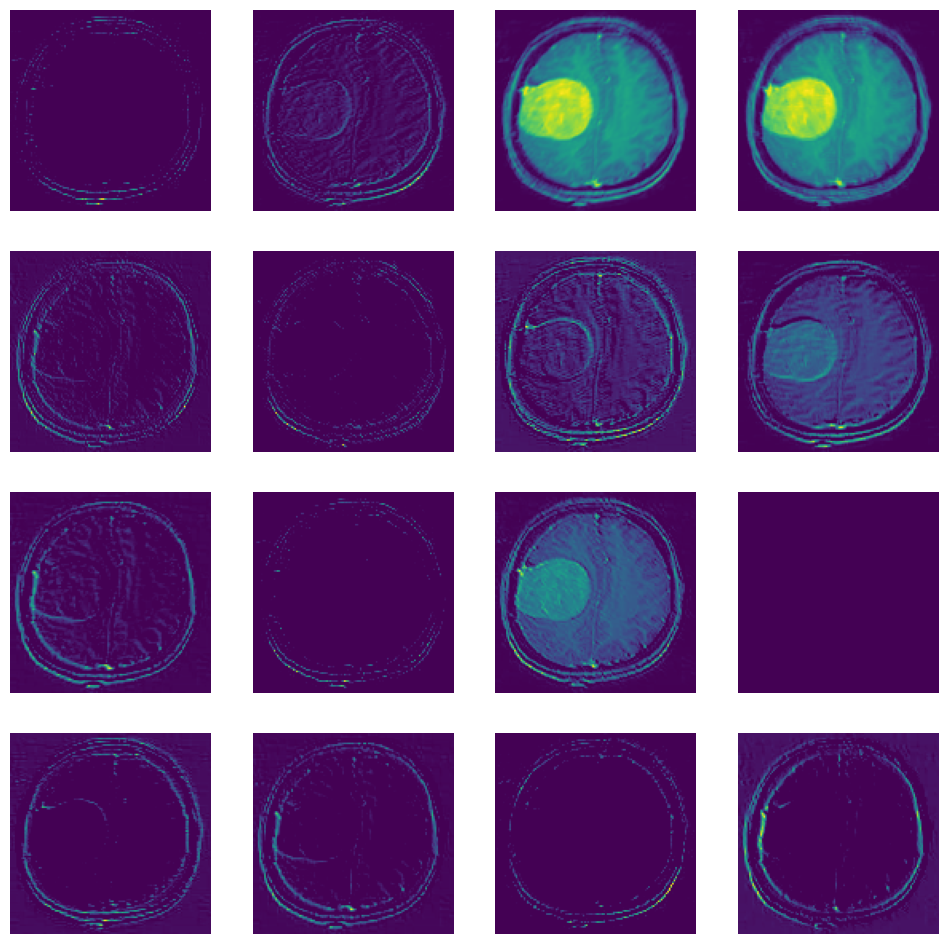

In [ ]:
from tensorflow import keras
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name] #output of all conv layer of cnn model


activation_model = Model(inputs=model.inputs, outputs=layer_outputs) #nw model going to store each feature mapping image of each conv layer

# Load image
img_path = "dataset/yes/Y1.jpg"
img = keras.preprocessing.image.load_img(img_path, target_size=(128,128))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

activations = activation_model.predict(img_array) #this is the output of model when one image is passed through it, it contains conv layer which consists features of each cnn model conv layer

# Plot filters
layer_activation = activations[0] #first conv layer from activation model, storing shapes,edges,textures of each conv cnn layer 32

plt.figure(figsize=(12,12))
for i in range(16): #no. of filters=feature map (32)
    plt.subplot(4,4,i+1)
    plt.imshow(layer_activation[0,:,:,i], cmap='viridis')
    plt.axis('off')
plt.show()

In [ ]:
import numpy as np
model(np.zeros((1,128,128,3)))  #building model so that it is initialized and have some input output thing

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.43063116]], dtype=float32)>

Using layer: last_conv
Prediction: [[0.99037826]]
Grads: tf.Tensor(
[[[[ 4.98807291e-04  0.00000000e+00  0.00000000e+00 ...  3.84976185e-04
     6.10393123e-04  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
     0.00000000e+00  0.00000000e+00]
   [ 3.66810156e-04  0.00000000e+00 -6.49564754e-07 ...  3.92204092e-04
     4.43478028e-04 -2.14725398e-04]
   ...
   [ 0.00000000e+00  1.08106149e-04  0.00000000e+00 ...  0.00000000e+00
     0.00000000e+00  0.00000000e+00]
   [ 2.34277453e-04  0.00000000e+00  3.57497804e-04 ...  4.36055707e-04
    -2.73256243e-04  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
     0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00  9.94259026e-04 ...  0.00000000e+00
     0.00000000e+00  5.93292993e-04]
   [ 0.00000000e+00  7.32589629e-04  0.00000000e+00 ...  0.00000000e+00
     0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  3.12627817e-04  0.00000000e+00

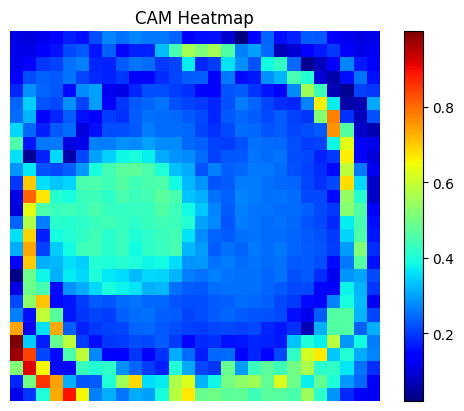

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Find last conv layer - Grad-CAM works best on last conv layer as it has:high-level features and spatial info
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Using layer:", last_conv_layer_name)

# Create grad model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.outputs[0]
    ]
)

# Load image
img_path = "/content/dataset/test/tumor/Y1.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Grad-CAM
with tf.GradientTape() as tape: #“How much each pixel affects prediction?”
    conv_outputs, predictions = grad_model(img_array)

    print("Prediction:", predictions.numpy())

    loss = predictions[0]

# Compute gradients
grads = tape.gradient(loss, conv_outputs) #importance of each pixel in feature map

print("Grads:", grads)

# STOP if grads None
if grads is None:
    raise Exception("❌ Gradients are None → model issue")

# Pool gradients
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2)) #Determines importance of each feature map

conv_outputs = conv_outputs[0]

# Heatmap
heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1) #Weighted sum of feature maps

#normalize -ve & 0,1
heatmap = np.maximum(heatmap, 0)
heatmap /= (np.max(heatmap) + 1e-8)

plt.imshow(heatmap, cmap='jet') #jet - red = important region & blue = less important
plt.title("CAM Heatmap")
plt.colorbar()
plt.axis('off')
plt.show()


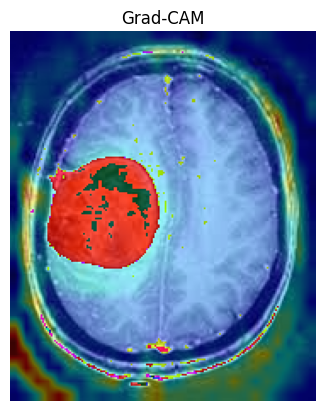

In [ ]:

# Superimpose
img = cv2.imread(img_path)
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img #blend og image with heatmap

# Show
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis('off')
plt.show()